# Proyecto 1 — Monitoreo transaccional

**Detectar lo que el orden revela**  
**Curso:** Deep Learning 2026  
**Integrantes:** _completar nombres y apellidos_

Este notebook carga artefactos congelados. No reentrena modelos ni vuelve a evaluar TEST.

In [1]:
from pathlib import Path
import csv, json
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
assert (ROOT / 'artefactos/final_results.json').is_file(), 'Ejecutar desde la raíz del repositorio'
results = json.loads((ROOT / 'artefactos/final_results.json').read_text())
decision = json.loads((ROOT / 'artefactos/final_decision_config.json').read_text())
evaluation = json.loads((ROOT / 'artefactos/final_evaluation.json').read_text())
falsification = json.loads((ROOT / 'artefactos/model_b/falsification_metadata.json').read_text())
processed = json.loads((ROOT / 'data/processed/processed_metadata.json').read_text())

def table(headers, rows):
    def fmt(x):
        if isinstance(x, float): return f'{x:.6f}'
        return str(x)
    lines=['| '+' | '.join(headers)+' |','|'+'|'.join(['---']*len(headers))+'|']
    lines += ['| '+' | '.join(fmt(x) for x in row)+' |' for row in rows]
    display(Markdown('\n'.join(lines)))

def figure(path, width=850):
    display(Image(filename=str(ROOT/path), width=width))

print('Estado experimental:', results['experimental_status'])
print('Fuente maestra: artefactos/final_results.json')

Estado experimental: CLOSED
Fuente maestra: artefactos/final_results.json


## 1. Pregunta de investigación

¿El orden cronológico de las transacciones aporta información útil para detectar fraude más allá de resúmenes causales del historial? Comparamos los tres modelos sobre los mismos targets y usamos Average Precision porque el fraude es minoritario.

## 2. Diseño experimental

A usa operación actual y agregados; B usa operación actual e historia ordenada; C combina ambas vistas. TRAIN ajusta parámetros, VALIDATION selecciona modelos y thresholds, y TEST se reserva para una única evaluación final.

## 3. Generación de datos

Dataset Version 1 es sintético y reproducible. Incluye perfiles legítimos, hard negatives y tres mecanismos: `testing_cashout`, `channel_takeover` y `amount_anomaly`.

| Transacciones | Tarjetas | Tasa fraude | Inicio | Fin | SHA-256 |
|---|---|---|---|---|---|
| 95767 | 2800 | 1.6446% | 2025-01-01T00:00:00 | 2025-06-29T23:59:59 | 1f659a437a417e08b4274da79bfba8853887b2d4888d235c87e4a5d4ce5cf95d |

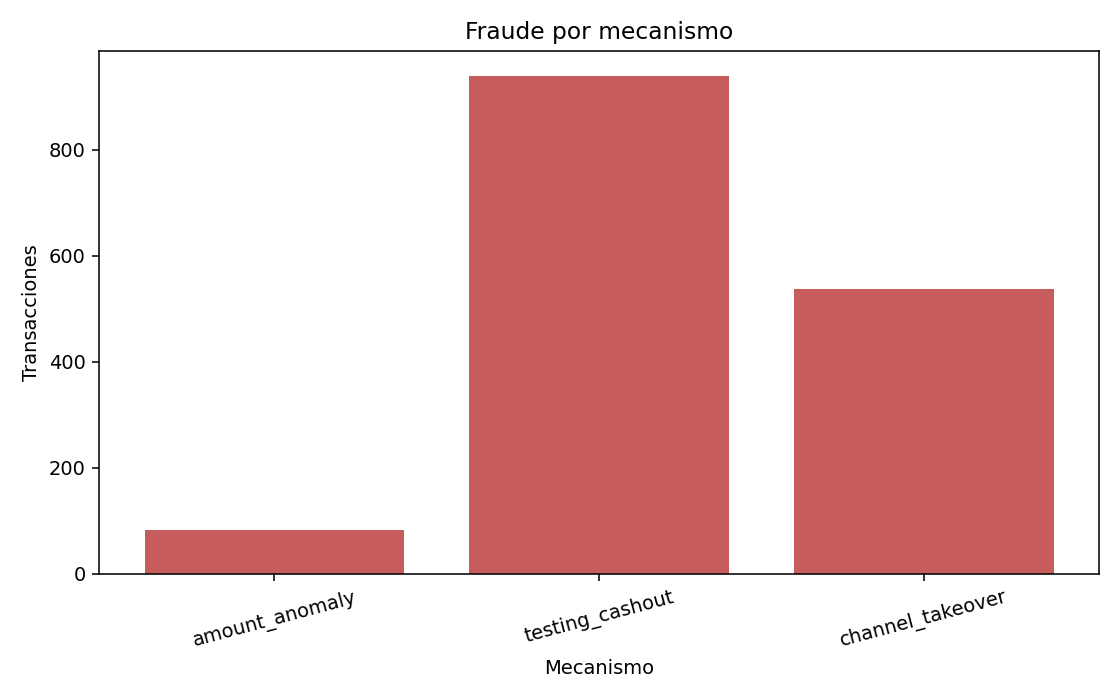

In [2]:
d=results['dataset']
table(['Transacciones','Tarjetas','Tasa fraude','Inicio','Fin','SHA-256'], [[d['transactions'],d['cards'],f"{d['fraud_rate']:.4%}",d['period_start'],d['period_end'],d['fingerprint_sha256']]])
figure('figures/eda_fraud_mechanisms.png', 720)

## 4. Integridad de datos

IDs, etiquetas, tipo de fraude y metadata del generador no entran como features. Cada ejemplo usa únicamente transacciones anteriores de la misma tarjeta. Las pruebas automáticas verifican causalidad, padding, universo común y ausencia de columnas prohibidas.

## 5. Partición temporal

Usamos los datos más antiguos para entrenar y dejamos los últimos para TEST. Esto evita que el modelo aprenda información que todavía no habría ocurrido en producción.

| Split | Inicio | Fin | Ejemplos | Fraudes |
|---|---|---|---|---|
| TRAIN | 2025-01-01T04:00:48 | 2025-05-07T06:01:10 | 64236 | 1110 |
| VALIDATION | 2025-05-07T06:10:15 | 2025-06-03T02:43:40 | 14365 | 228 |
| TEST | 2025-06-03T02:55:10 | 2025-06-29T23:59:59 | 14366 | 222 |

Orden temporal verificado. Fit de preprocessing: train


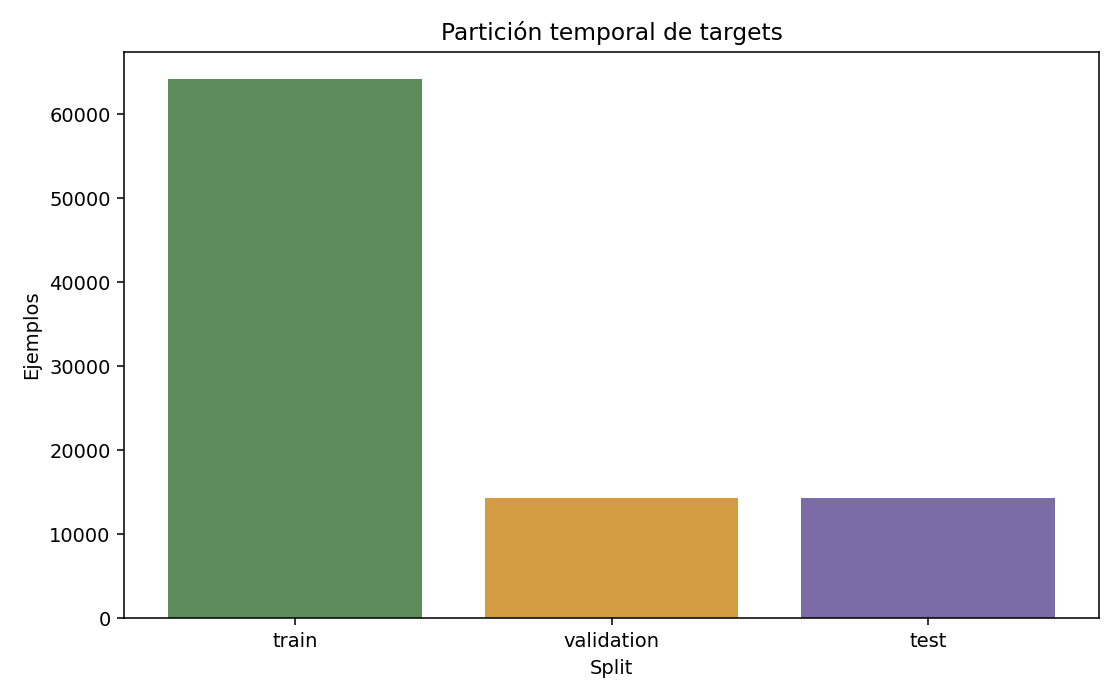

In [3]:
table(['Split','Inicio','Fin','Ejemplos','Fraudes'], [[name.upper(),x['start'],x['end'],x['n'],x['frauds']] for name,x in results['splits'].items()])
assert results['splits']['train']['end'] < results['splits']['validation']['start'] < results['splits']['validation']['end'] < results['splits']['test']['start']
print('Orden temporal verificado. Fit de preprocessing:', processed['fit_split'])
figure('figures/eda_temporal_split.png', 800)

## 6. Construcción de ejemplos

Se excluye solo la primera operación de cada tarjeta. A recibe 23 agregados causales; B/C reciben hasta 12 eventos previos con left padding, PAD=0, UNK=1 y longitud válida. La operación objetivo siempre está separada de la historia.

In [4]:
table(['Ejemplos','MAX_HISTORY','Agregados','Current numéricas','Secuencia por evento'], [[processed['n_examples'],processed['max_history'],len(processed['aggregate_features']),len(processed['current_numeric_features']),len(processed['sequence_numeric_features'])+len(processed['sequence_categorical_features'])]])

| Ejemplos | MAX_HISTORY | Agregados | Current numéricas | Secuencia por evento |
|---|---|---|---|---|
| 92967 | 12 | 23 | 8 | 10 |

## 7. Modelo A — Sin orden

HistGradientBoosting usa la operación actual y agregados históricos. Es un baseline competitivo, no una referencia debilitada.

## 8. Modelo B — Secuencia ordenada

La GRU unidireccional procesa hasta 12 eventos anteriores; otra rama procesa la operación actual. No recibe los agregados de A.

| Modelo | Información | Validation AP |
|---|---|---|
| A | current + agregados | 0.910021 |
| B | current + secuencia | 0.720674 |

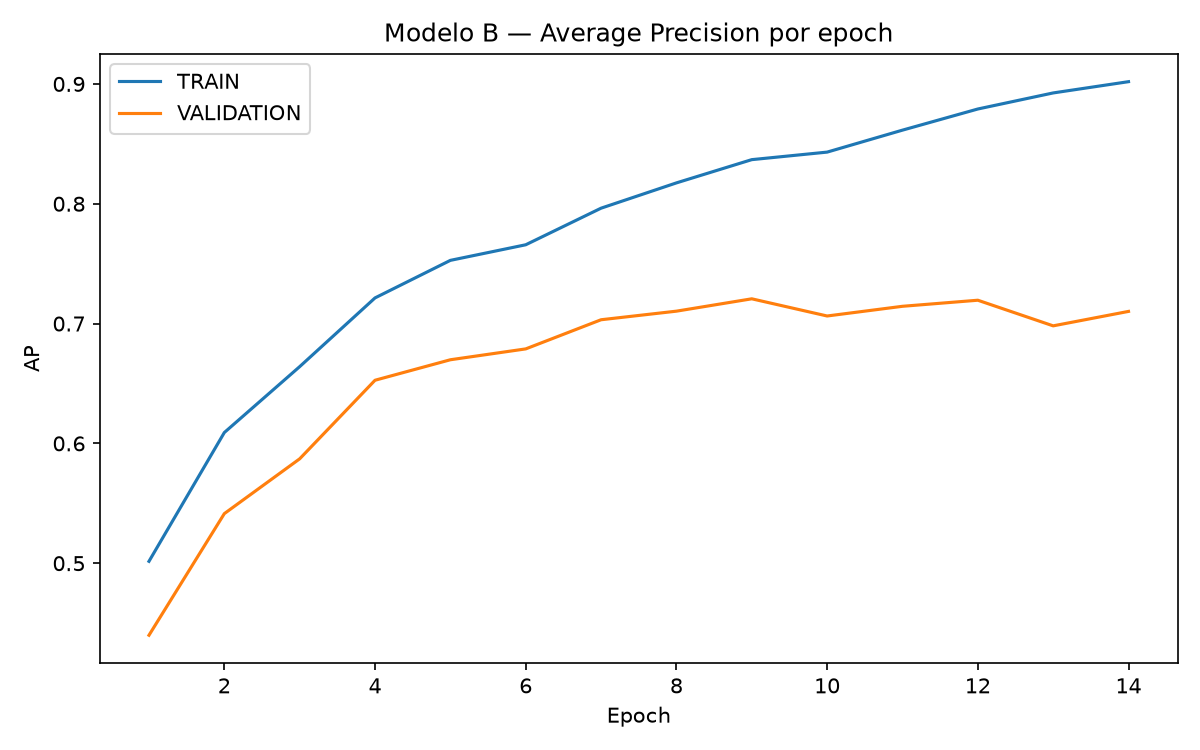

In [5]:
table(['Modelo','Información','Validation AP'], [['A','current + agregados',results['models']['A']['validation_ap']],['B','current + secuencia',results['models']['B']['validation_ap']]])
figure('figures/model_b_training_ap.png', 760)

## 9. ¿El orden realmente aporta?

### Permutación controlada

Barajamos dentro de cada historia los mismos eventos, manteniendo operación actual, target, longitud y checkpoint.

### Historia recortada

Con el mismo checkpoint conservamos solamente los tres eventos más recientes.

| Condición | Validation AP | Cambio vs original |
|---|---|---|
| B original | 0.720674 | 0 |
| B permutado (media) | 0.284325 | -0.436349 |
| B historia ≤3 | 0.710823 | -0.009850 |

Permutación std: 0.020168
Interpretación: B usa el orden, pero la historia del cuarto al duodécimo evento añadió poco y B no superó a A.


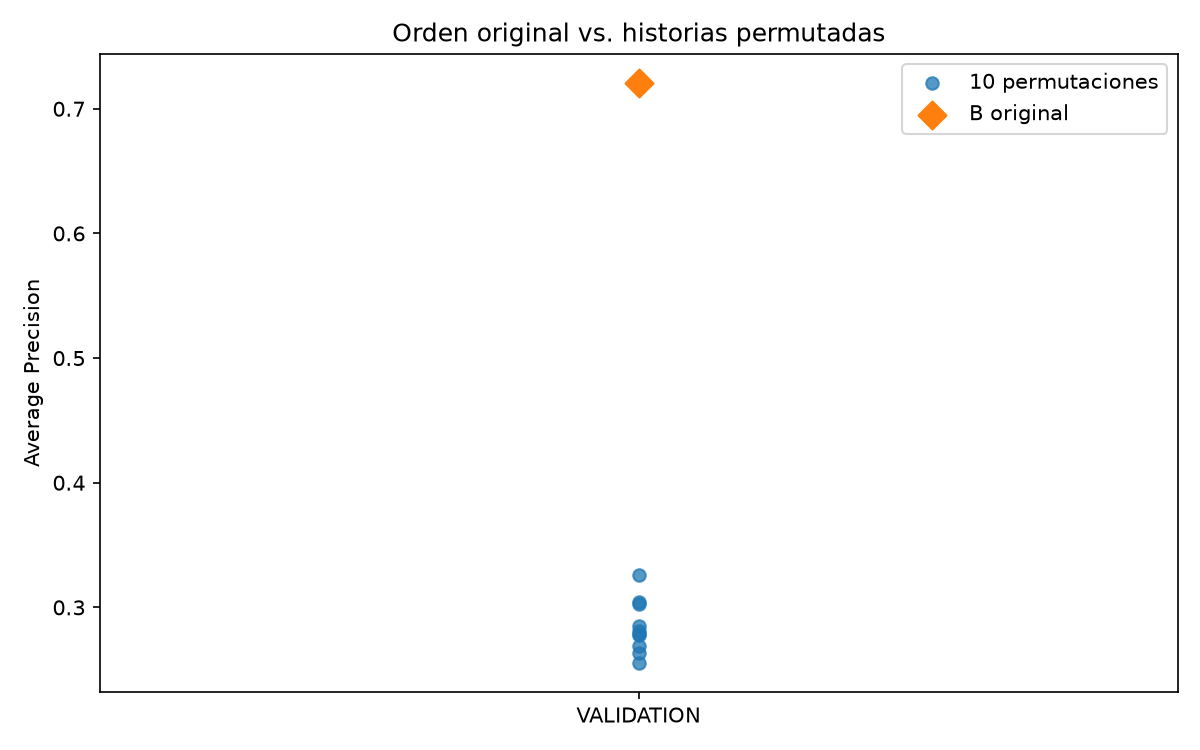

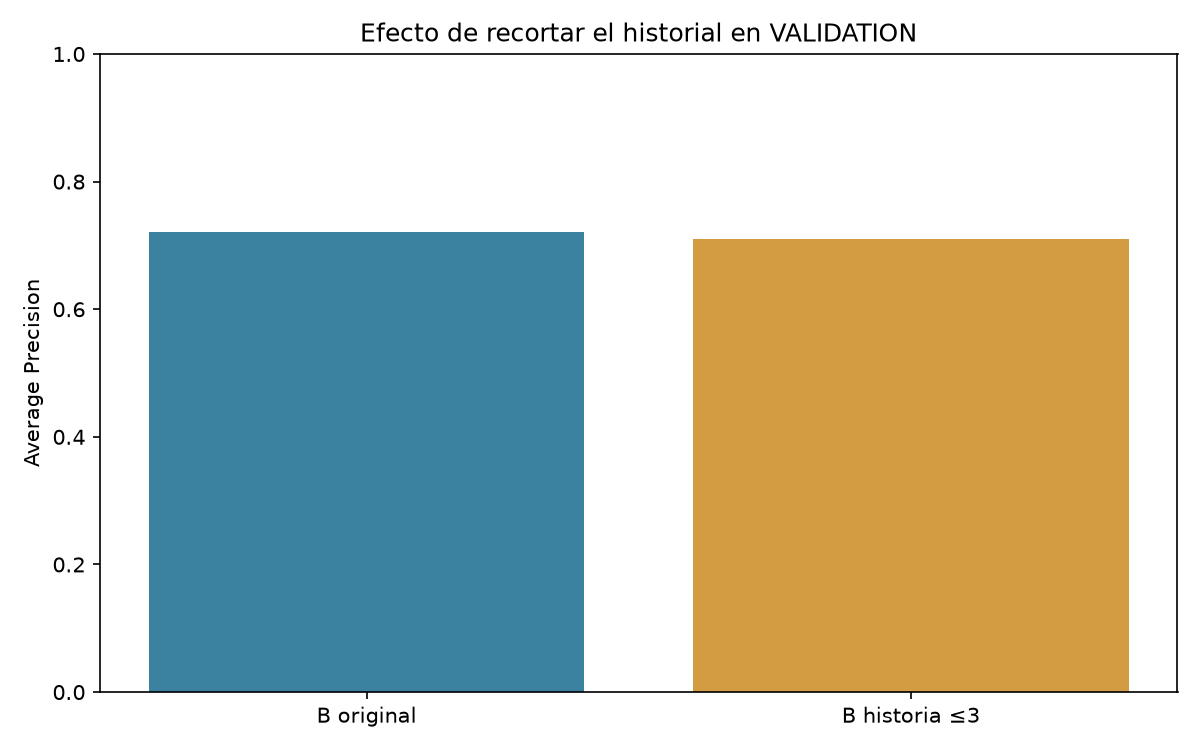

In [6]:
f=results['falsification']
table(['Condición','Validation AP','Cambio vs original'], [['B original',f['model_b_original_validation_ap'],0],['B permutado (media)',f['permuted_mean_ap'],-f['absolute_drop']],['B historia ≤3',f['short_history_ap'],f['short_history_ap']-f['model_b_original_validation_ap']]])
print(f"Permutación std: {f['permuted_std_ap']:.6f}")
print('Interpretación: B usa el orden, pero la historia del cuarto al duodécimo evento añadió poco y B no superó a A.')
figure('figures/order_permutation_validation.png', 760)
figure('figures/history_truncation_validation.png', 760)

## 10. Apuesta C — Modelo híbrido

**Hipótesis previa:** secuencia y agregados capturan señales complementarias. **Control:** B. **Criterio:** superar B en VALIDATION y no empeorar el costo. C se entrenó desde cero.

| Modelo | Validation AP |
|---|---|
| A | 0.910021 |
| B | 0.720674 |
| C | 0.815180 |

Ablación C normal: 0.815180; agregados neutralizados: 0.429477.
Veredicto: C mejoró B y usó los agregados, pero quedó debajo de A y no logró ventaja económica final.


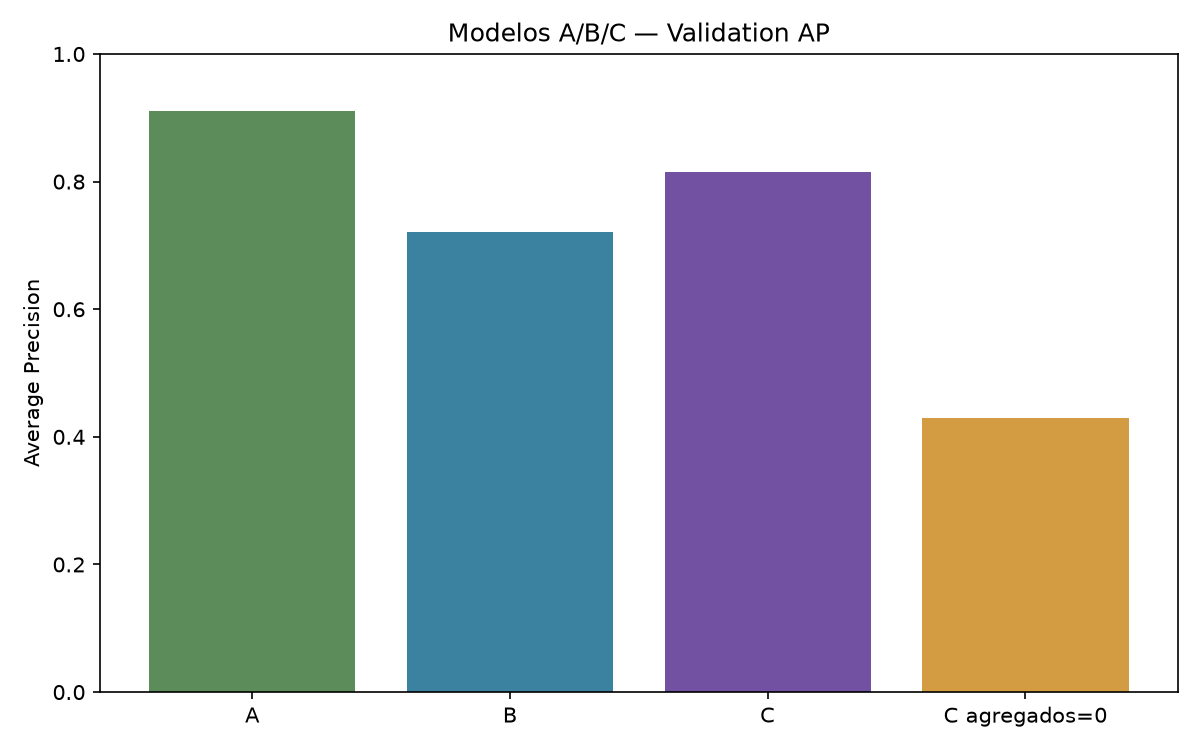

In [7]:
cmeta=json.loads((ROOT/'artefactos/model_c/model_c_metadata.json').read_text())
table(['Modelo','Validation AP'], [[m,results['models'][m]['validation_ap']] for m in ('A','B','C')])
print(f"Ablación C normal: {cmeta['ablation_normal_ap']:.6f}; agregados neutralizados: {cmeta['ablation_aggregates_neutral_ap']:.6f}.")
print('Veredicto: C mejoró B y usó los agregados, pero quedó debajo de A y no logró ventaja económica final.')
figure('figures/model_abc_validation_comparison.png', 760)

## 11. Selección del threshold

Un score todavía no es una decisión. Minimizamos `FN × Q4,200 + FP × Q180` exclusivamente en VALIDATION. Si hay empate exacto, usamos el threshold más alto para reducir bloqueos legítimos.

| Modelo | Threshold | FP | FN | Precision | Recall | F1 | Costo Validation |
|---|---|---|---|---|---|---|---|
| A | 0.055489 | 212 | 11 | 0.505828 | 0.951754 | 0.660578 | Q84,360 |
| B | 0.825399 | 406 | 41 | 0.315346 | 0.820175 | 0.455542 | Q245,280 |
| C | 0.668239 | 333 | 27 | 0.376404 | 0.881579 | 0.527559 | Q173,340 |

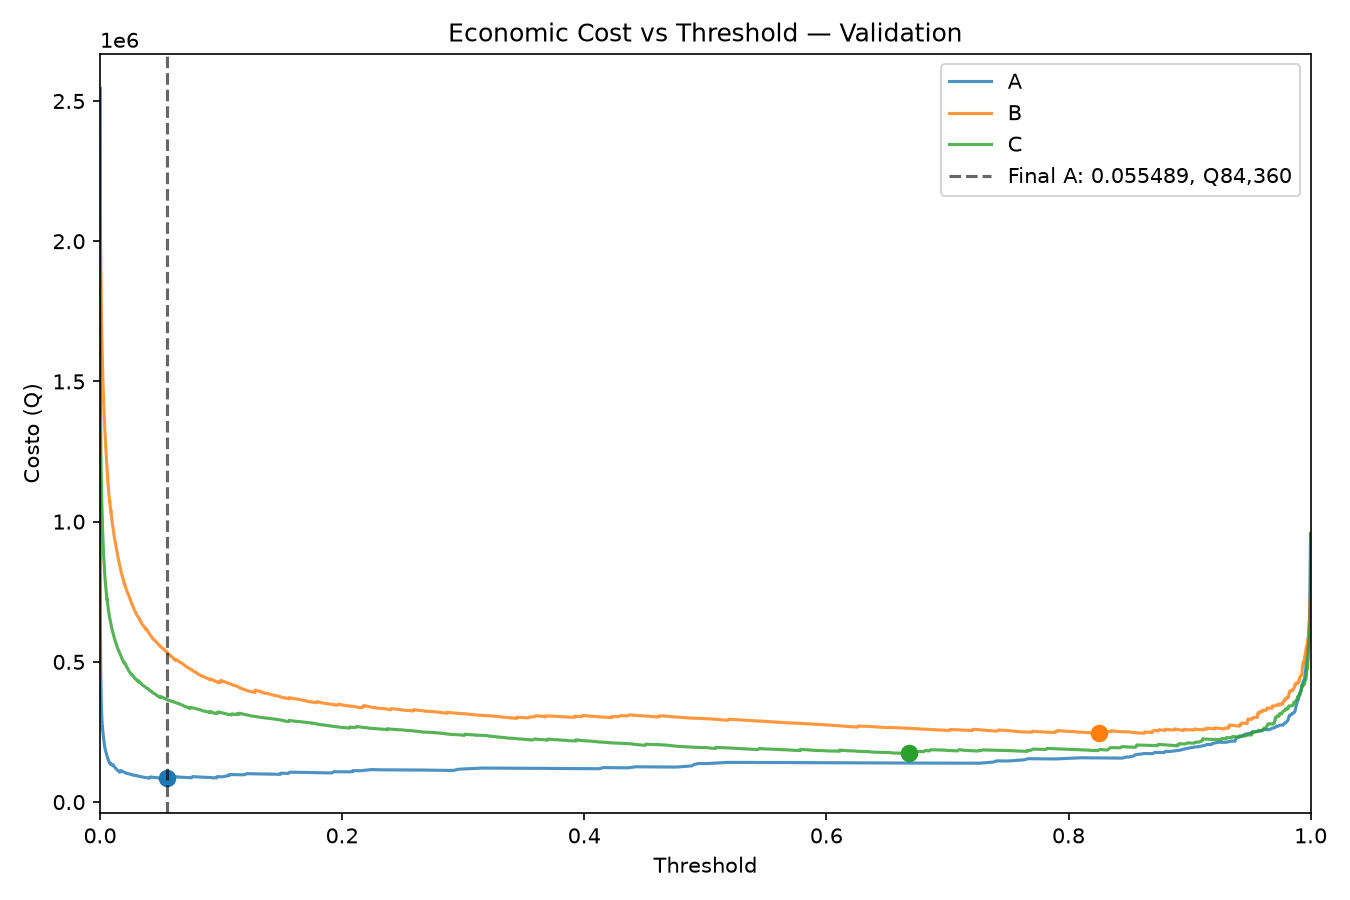

In [8]:
table(['Modelo','Threshold','FP','FN','Precision','Recall','F1','Costo Validation'], [[m,decision['validation_thresholds'][m],decision['validation_metrics_at_threshold'][m]['FP'],decision['validation_metrics_at_threshold'][m]['FN'],decision['validation_metrics_at_threshold'][m]['precision'],decision['validation_metrics_at_threshold'][m]['recall'],decision['validation_metrics_at_threshold'][m]['F1'],f"Q{decision['validation_metrics_at_threshold'][m]['economic_cost']:,}"] for m in ('A','B','C')])
figure('figures/economic_cost_vs_threshold_validation.png', 850)

---
# ANTES DE TEST — DECISIONES CONGELADAS

El candidato, checkpoint y los tres thresholds quedaron escritos antes de abrir TEST. A partir de este punto no se modificó ninguna decisión según los resultados finales.

In [9]:
display(Markdown(f"**Candidato:** {decision['candidate_model']}  \
**Threshold:** `{decision['final_threshold']}`  \
**Checkpoint:** `{decision['candidate_checkpoint']}`  \
**Razón:** {decision['selection_reason']}  \
**Snapshot pre-TEST SHA-256:** `{decision['pre_test_config_sha256']}`"))

**Candidato:** A  **Threshold:** `0.05548898134596948`  **Checkpoint:** `artefactos/model_a/model_a.joblib`  **Razón:** A obtuvo el mayor AP congelado en VALIDATION (0.9100 frente a 0.8152 de C y 0.7207 de B) y también el menor costo económico de VALIDATION. B sí mostró valor del orden bajo permutación, y C mejoró B, pero ninguno superó al sistema agregado A en la evidencia usada antes de TEST.  **Snapshot pre-TEST SHA-256:** `86c7f7f6bbf9cff302d69fa840c1157d43d4710106023cbd13170b1e8fa21d98`

---
# DESPUÉS DE TEST — EVALUACIÓN FINAL ÚNICA

Las siguientes métricas son descriptivas. No se usaron para cambiar candidato, threshold, features o arquitectura.

## 13. Evaluación final

| Modelo | Validation AP | Test AP | Threshold | Precision | Recall | F1 | TP | FP | TN | FN | Costo |
|---|---|---|---|---|---|---|---|---|---|---|---|
| A | 0.910021 | 0.919108 | 0.055489 | 0.502381 | 0.950450 | 0.657321 | 211 | 209 | 13935 | 11 | Q83,820 |
| B | 0.720674 | 0.715009 | 0.825399 | 0.302326 | 0.878378 | 0.449827 | 195 | 450 | 13694 | 27 | Q194,400 |
| C | 0.815180 | 0.824840 | 0.668239 | 0.377820 | 0.905405 | 0.533156 | 201 | 331 | 13813 | 21 | Q147,780 |

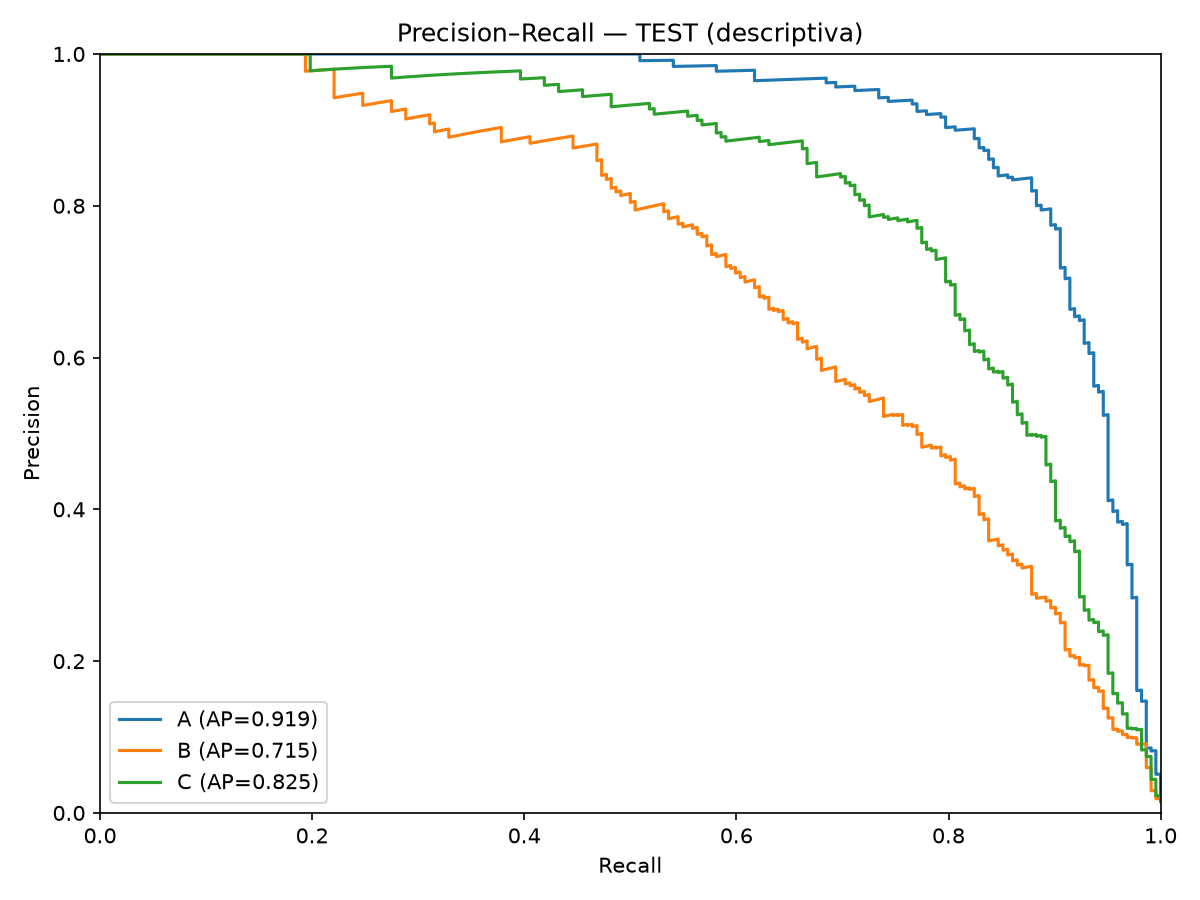

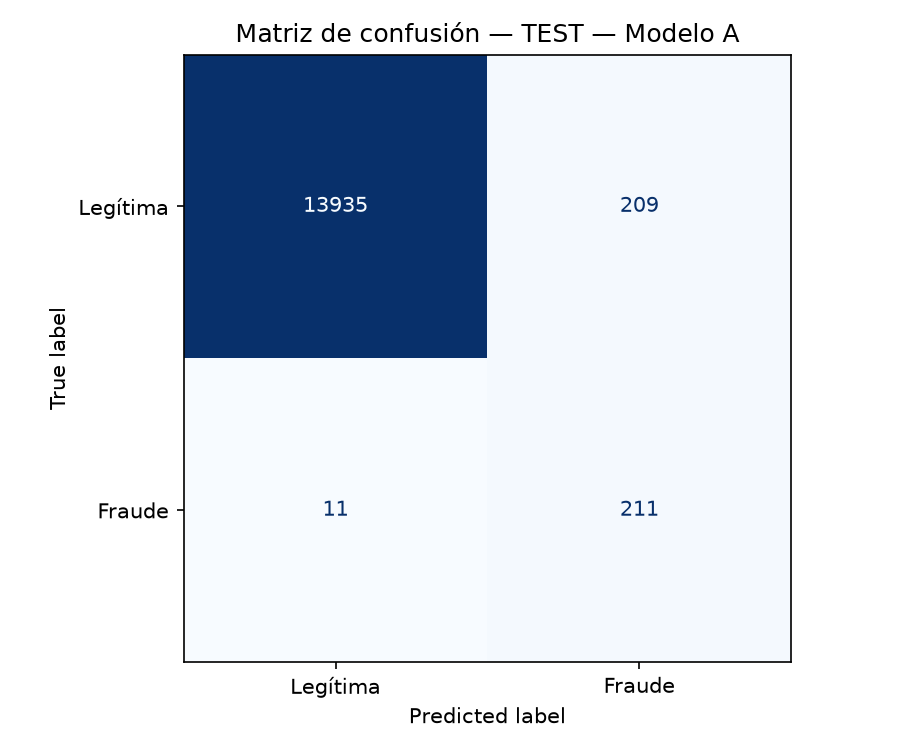

In [10]:
table(['Modelo','Validation AP','Test AP','Threshold','Precision','Recall','F1','TP','FP','TN','FN','Costo'], [[m,x['validation_ap'],x['test_ap'],x['threshold'],x['precision'],x['recall'],x['f1'],x['tp'],x['fp'],x['tn'],x['fn'],f"Q{x['cost_gtq']:,}"] for m,x in results['models'].items()])
figure('figures/test_pr_curves_abc.png', 800)
figure('figures/test_confusion_matrix_final_candidate.png', 650)

## 14. Impacto económico

Los costos son una aproximación académica: no garantizan que cada verdadero positivo ahorre exactamente Q4,200. La normalización mensual usa 30.44 días y conserva la escala del dataset sintético.

| Referencia | Costo TEST |
|---|---|
| Never Block | Q932,400 |
| Block Everything | Q2,545,920 |
| Modelo A | Q83,820 |
| Candidato | Q83,820 |

Periodo TEST: 26.8783 días. Equivalente mensual candidato: Q94,927.01. Savings vs A: Q0.
No extrapolar directamente a 1.4 millones de tarjetas.


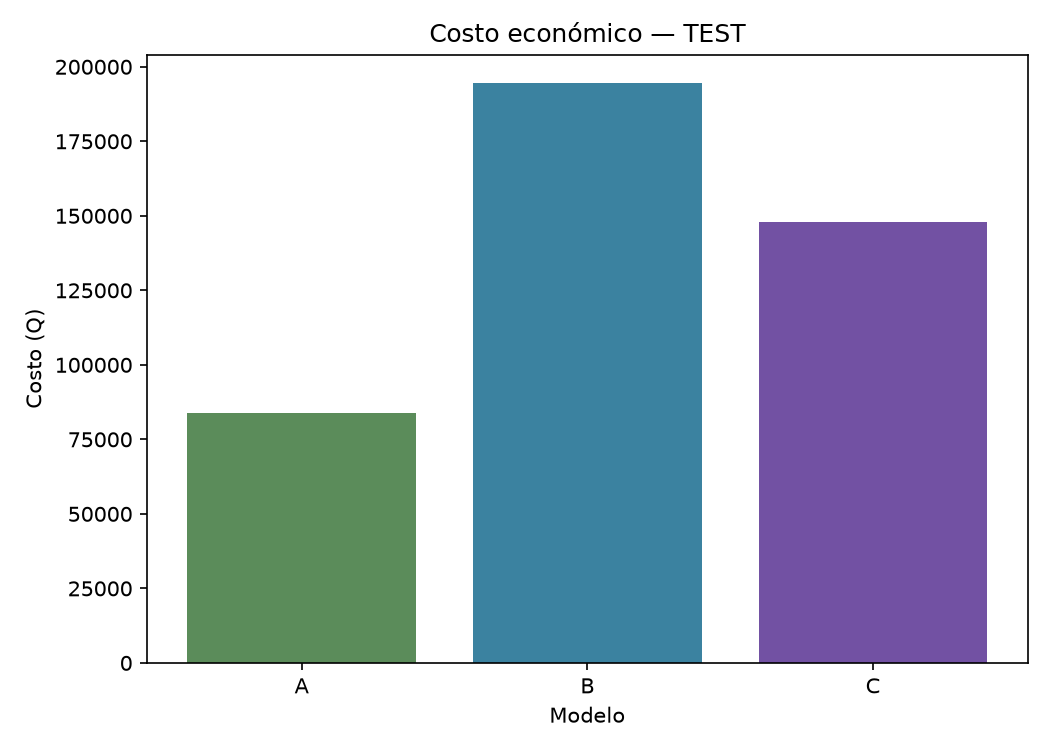

In [11]:
e=results['economics']; b=evaluation['test_baselines']
table(['Referencia','Costo TEST'], [['Never Block',f"Q{b['never_block_cost']:,}"],['Block Everything',f"Q{b['block_everything_cost']:,}"],['Modelo A',f"Q{e['cost_A_gtq']:,}"],['Candidato',f"Q{e['cost_candidate_gtq']:,}"]])
print(f"Periodo TEST: {e['test_days']:.4f} días. Equivalente mensual candidato: Q{e['monthly_equivalent_candidate_gtq']:,.2f}. Savings vs A: Q{e['savings_vs_A_gtq']:,}.")
print('No extrapolar directamente a 1.4 millones de tarjetas.')
figure('figures/test_economic_cost_abc.png', 720)

## 15. Análisis de errores

Mostramos pocos casos representativos. Los archivos completos de análisis contienen diez FN y diez FP seleccionados por mecanismo/tipo y nivel de score, no solo los extremos.

| Mecanismo | n | Detectados | No detectados | Recall |
|---|---|---|---|---|
| testing_cashout | 134 | 133 | 1 | 0.992537 |
| channel_takeover | 75 | 71 | 4 | 0.946667 |
| amount_anomaly | 13 | 7 | 6 | 0.538462 |

### False negatives

| transaction_id | tipo | amount | channel | merchant | history | score |
|---|---|---|---|---|---|---|
| TX_000087462 | amount_anomaly | 5296.1 | POS | travel | 12 | 0.00024833871559285425 |
| TX_000091567 | amount_anomaly | 752.95 | CONTACTLESS | travel | 12 | 0.002176958399057909 |
| TX_000087906 | amount_anomaly | 6181.11 | POS | retail | 12 | 0.009791968610758046 |
| TX_000083935 | channel_takeover | 411.32 | CONTACTLESS | restaurant | 12 | 0.01497374830134143 |
| TX_000084127 | channel_takeover | 112.56 | ATM | retail | 12 | 0.022704558098910317 |

### False positives

| transaction_id | tipo | amount | channel | merchant | history | score |
|---|---|---|---|---|---|---|
| TX_000083367 | legitimate_micro_purchases | 14.88 | CONTACTLESS | services | 12 | 0.08615520521799033 |
| TX_000088985 | legitimate_micro_purchases | 7.37 | CONTACTLESS | services | 12 | 0.8854314580414515 |
| TX_000085776 | legitimate_micro_purchases | 11.04 | ONLINE | services | 12 | 0.9948007363184652 |
| TX_000084308 | legitimate_shopping_spree | 259.28 | CONTACTLESS | retail | 12 | 0.056849414093523315 |
| TX_000093093 | legitimate_shopping_spree | 30.17 | CONTACTLESS | retail | 12 | 0.08739204882462574 |

Patrón principal: 6 de 11 FN son amount_anomaly. En FP no encontramos un patrón único.


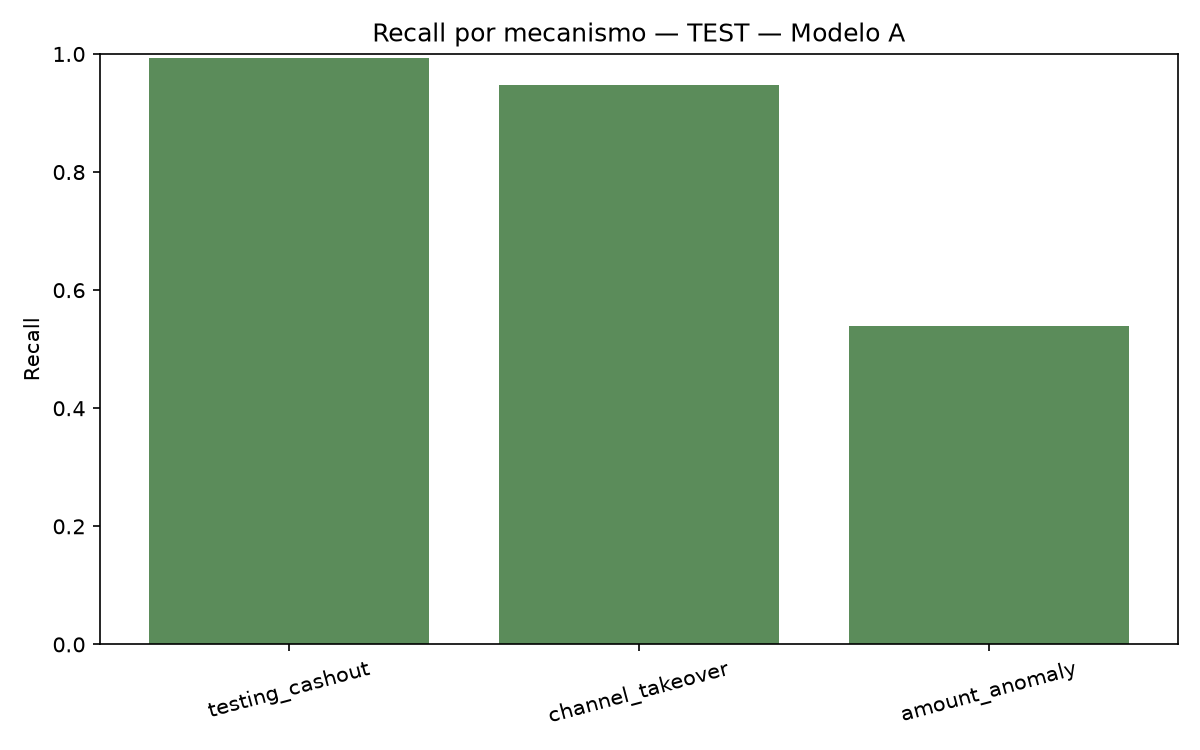

In [12]:
mech=evaluation['candidate_mechanisms']
table(['Mecanismo','n','Detectados','No detectados','Recall'], [[k,v['n'],v['detected'],v['missed'],v['recall']] for k,v in mech.items()])
for title,file in [('False negatives','experiments/final_candidate_false_negatives.csv'),('False positives','experiments/final_candidate_false_positives.csv')]:
    with (ROOT/file).open(newline='') as h: rows=list(csv.DictReader(h))[:5]
    display(Markdown('### '+title)); table(['transaction_id','tipo','amount','channel','merchant','history','score'], [[r['transaction_id'],r['fraud_type'] if r['fraud_type']!='legitimate' else r['hard_negative_type'],r['amount'],r['channel'],r['merchant'],r['history_length'],r['risk_score']] for r in rows])
print('Patrón principal: 6 de 11 FN son amount_anomaly. En FP no encontramos un patrón único.')
figure('figures/test_recall_by_mechanism_candidate.png', 780)

## 16. Recomendación

**CONSERVAR.** B demostró valor del orden y C aprovechó información complementaria, pero ambos tuvieron menor AP y mayor costo que A. El hallazgo temporal es científicamente útil, aunque no justifica reemplazar el sistema agregado en este experimento.

## 17. Limitaciones

- Los datos y mecanismos son sintéticos; falta validación bancaria real.
- Los costos Q4,200/Q180 son promedios simplificados.
- La cifra mensual conserva la escala simulada.
- A tuvo 209 falsos positivos y recall de solo 53.85% en `amount_anomaly`.
- MAX_HISTORY=12 limita el horizonte estudiado.
- Un cambio temporal de conducta puede producir drift.
- Antes de bloqueo automático se necesitan gobernanza, límites operativos y revisión de impacto.

El modelado está cerrado. Las fuentes maestras son `artefactos/final_results.json`, `artefactos/final_evaluation.json` y `evidence_matrix.csv`.